In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
import regionmask
from shapely.geometry import box
from matplotlib.colors import ListedColormap
import numpy as np

## Open shapeFile

## Open shape files

<Axes: >

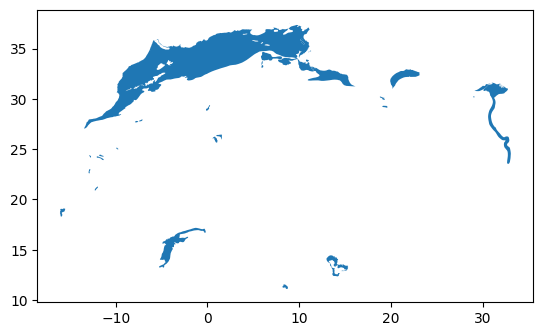

In [2]:
shp_file =gpd.read_file('./modifiedAfrica/modifiedAfrica.shp')
shp_file.plot()

<Axes: >

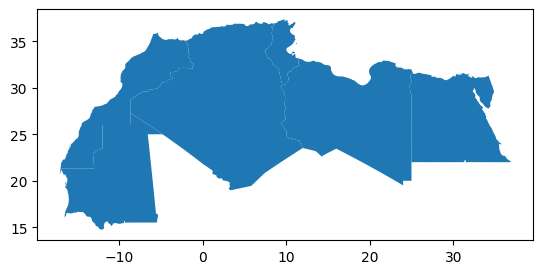

In [3]:
shp_NorthAfrica = gpd.read_file('./shapeFileWholeWorld/World_Countries_Generalized.shp')
shp_NorthAfrica = shp_NorthAfrica[shp_NorthAfrica['COUNTRY'].isin(['Mauritania', 'Algeria', 'Morocco', 'Tunisia', 'Libya', 'Egypt'])] 
shp_NorthAfrica = shp_NorthAfrica.to_crs("EPSG:4326")
shp_NorthAfrica.plot()

## Plot data

In [4]:
def plotRaster(ds, shp_file, shp_NorthAfrica, var, color, year):
    ds = ds.rio.write_crs("EPSG:4326", inplace=True)
    ds = ds.rio.clip(shp_file.geometry,shp_file.crs,drop=False)
    
    fig, ax = plt.subplots(figsize=(10,5))
    pp = ds['band_data'][0].plot(ax=ax, cmap=color, add_colorbar=False)
    shp_file.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
    shp_NorthAfrica.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
    
    #ax.set_title(f"{var} Normal 2000-2020")
    ax.set_title(f"{var} Anomally {year}")
    ax.set_xlabel("")
    ax.set_ylabel("")

    fig.colorbar(pp, shrink=0.6, location='right',  pad=0.05)

    plt.savefig(f'./fig/anomaly{var}{year}.jpg', dpi=300, bbox_inches='tight')
    plt.show()

    xr_min = np.array(ds['band_data'][0].min())
    xr_max = np.array(ds['band_data'][0].max())
    return(xr_min, xr_max)

In [10]:
def plotRasterAnomally(ds, vmin, vmax, shp_file, shp_NorthAfrica, var, color, year):
    ds = ds.rio.write_crs("EPSG:4326", inplace=True)
    ds = ds.rio.clip(shp_file.geometry,shp_file.crs,drop=False)
    
    fig, ax = plt.subplots(figsize=(10,5))
    pp = ds['band_data'][0].plot(ax=ax, vmin=vmin, vmax=vmax, cmap=color, add_colorbar=False)
    shp_file.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
    shp_NorthAfrica.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
    
    #ax.set_title(f"{var} Normal 2000-2020")
    ax.set_title(f"{var} Anomally {year}")
    ax.set_xlabel("")
    ax.set_ylabel("")

    fig.colorbar(pp, shrink=0.6, location='right',  pad=0.05)

    plt.savefig(f'./fig/anomaly{var}{year}.jpg', dpi=300, bbox_inches='tight')
    plt.show()

    xr_min = np.array(ds['band_data'][0].min())
    xr_max = np.array(ds['band_data'][0].max())
    return(xr_min, xr_max)

## Open dataFile

#### NDVI: -1:1; -1:water - 0:1 vegitation
#### NDWI -1:1; (<0): no water, 0:0.3:land and water, >0.3:waterbody may be sea

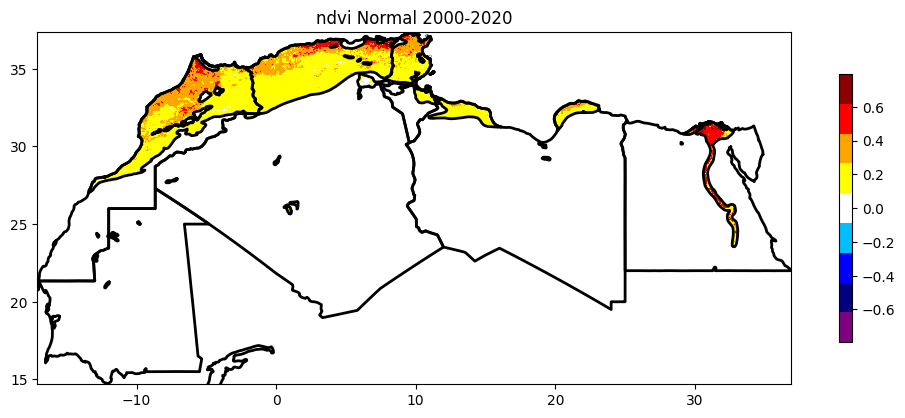

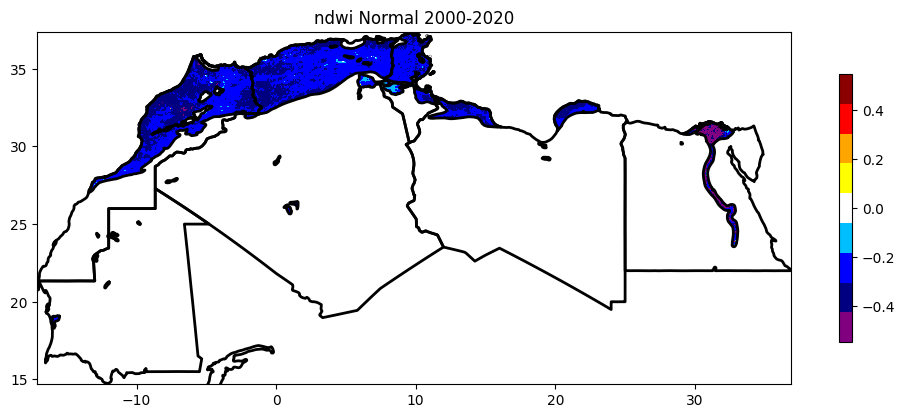

In [35]:
year = 2020
vars = ['ndvi', 'ndwi', 'rain', 'ssm']
colors = ['purple', 'navy', 'blue', 'deepskyblue', 'white', 'yellow', 'orange', 'red', 'darkred']
cmap = ListedColormap(colors=colors)

#colors = ['PiYG', 'RdBu', 'Blues', 'YlGn']
for v in range(2):
    ds = xr.open_dataset(f"./data/africa_{vars[v]}2020.tif")
    plotRaster(ds, shp_file, shp_NorthAfrica, vars[v], cmap, year)

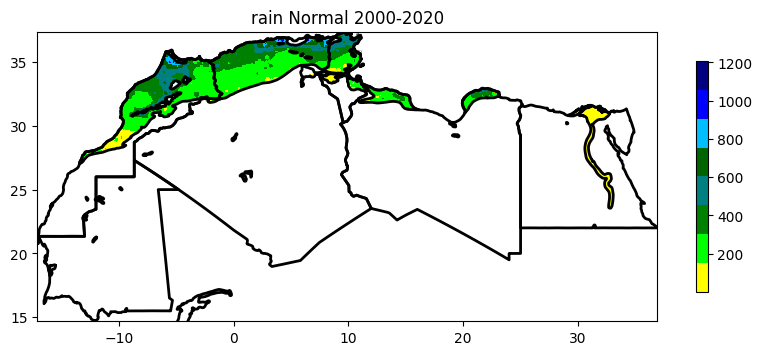

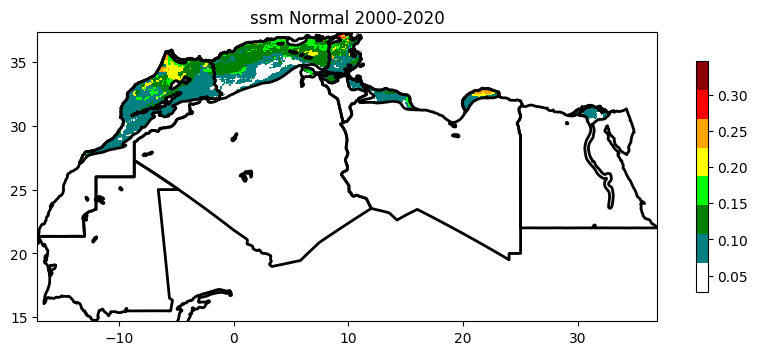

In [44]:
year = 2020
vars = ['rain', 'ssm']
colors = [['yellow', 'lime', 'green', 'teal', 'darkGreen', 'deepskyblue', 'blue', 'navy'],
          ['white', 'teal', 'green', 'lime', 'yellow', 'orange', 'red', 'darkred'] ]

#colors = ['PiYG', 'RdBu', 'Blues', 'YlGn']
for v in range(0,2):
    ds = xr.open_dataset(f"./data/africa_{vars[v]}2020.tif")
    plotRaster(ds, shp_file, shp_NorthAfrica, vars[v], ListedColormap(colors=colors[v]), year)

# 2021

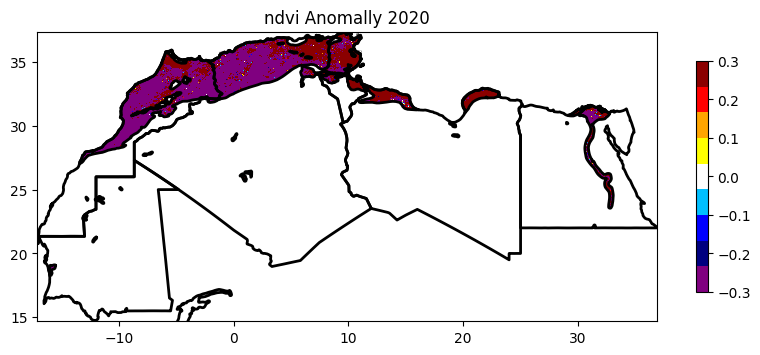

-511.0436296278206 1950.8626273718853


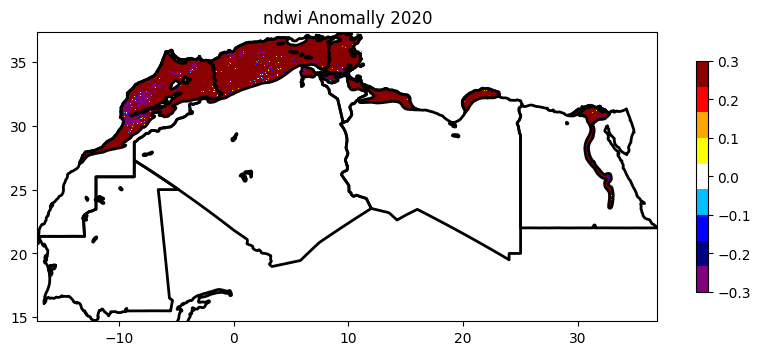

-1158.2268 47289.285


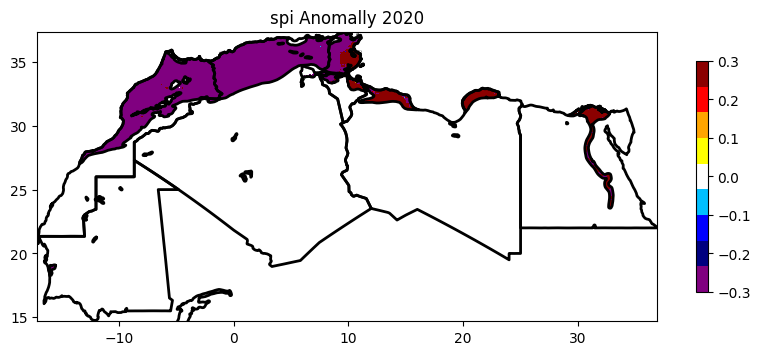

-99.16759229842765 339.65465495556094


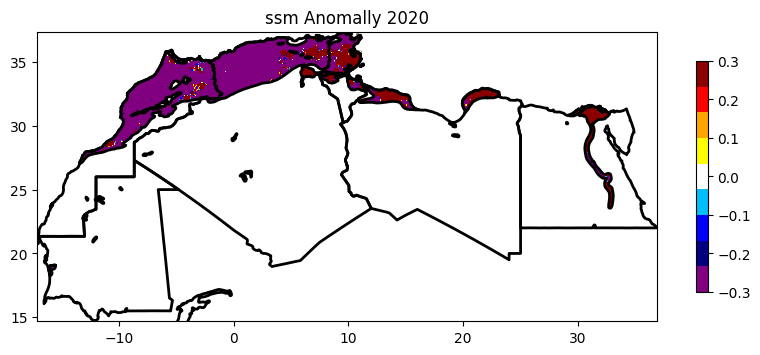

-26.861658 26.57235


In [45]:
year = 2020
vars = ['ndvi', 'ndwi', 'spi', 'ssm']
colors = ['purple', 'navy', 'blue', 'deepskyblue', 'white', 'yellow', 'orange', 'red', 'darkred']
cmap = ListedColormap(colors=colors)

for v in range(len(vars)):
    ds = xr.open_dataset(f"./data/Africa_{vars[v]}Anomaly_{year}.tif")
    ds1 = xr.open_dataset(f"./data/Africa_{vars[v]}Anomaly_{year}.tif")
    ds2 = xr.open_dataset(f"./data/Africa_{vars[v]}2020.tif")
    #ds = ds1 / ds2
    xr_min, xr_max = plotRasterAnomally(ds, -0.3, 0.3, shp_file, shp_NorthAfrica, vars[v], cmap, year)
    print(xr_min, xr_max)

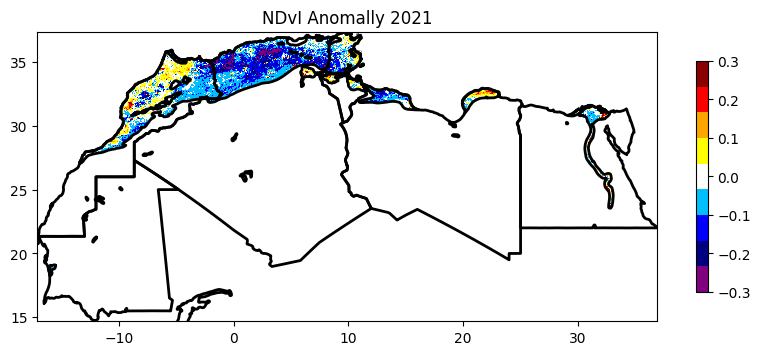

(array(-8.248755, dtype=float32), array(5.334881, dtype=float32))

In [49]:
ds1 = xr.open_dataset(f"Africa_ndviAnomaly_2021.tif")
ds2 = xr.open_dataset(f"./data/Africa_ndvi2020.tif")
ds = (ds1 / ds2)

colors = ['purple', 'navy', 'blue', 'deepskyblue', 'white', 'yellow', 'orange', 'red', 'darkred']
cmap = ListedColormap(colors=colors)
xr_min, xr_max = plotRasterAnomally(ds.astype("float32"), -0.3, 0.3, shp_file, shp_NorthAfrica, 'NDvI', cmap, 2021)
xr_min, xr_max

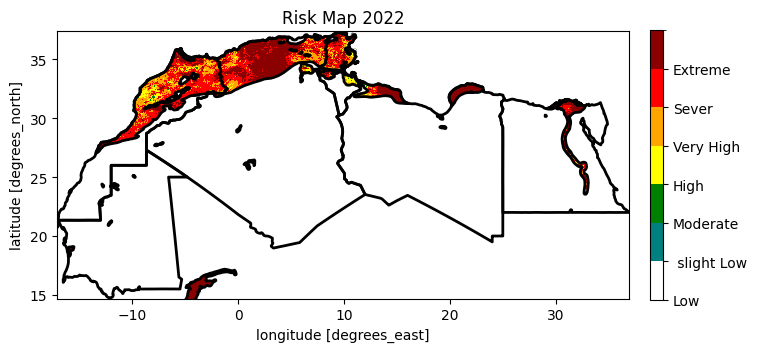

In [72]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib as mpl


year = 2022
#colors = ['#FFFFFF', '#ADD8E6', '#7FFF00', '#FFFF00',  '#FFA500', '#FF0000', '#800000']
#colors = ['white', 'green', 'lime', 'yellow', 'orange', 'red', 'darkred']
colors = ['white', 'teal', 'green', 'yellow', 'orange', 'red', 'darkred']
risk_labels = ['Low', ' slight Low', 'Moderate', 'High', 'Very High', 'Sever', 'Extreme']


risk_cmap = ListedColormap(colors[::-1])

risk_data = xr.open_dataset(f"./data/Africa_Drought_Classes_{year}.tif")
risk_data = risk_data.rio.clip(shp_file.geometry, shp_file.crs, drop=False, invert=False)


fig, ax = plt.subplots(figsize=(9,5))

pp = risk_data['band_data'][0].plot(ax=ax, cmap=risk_cmap, vmin=1, vmax=7, add_colorbar=False)
shp_file.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
shp_NorthAfrica.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)

"""
# --- 7. Add colorbar with labels centered on colors
bounds = np.arange(0.5, 8.5, 1)  # defines color boundaries (1–7)
cbar = fig.colorbar(pp, ax=ax, boundaries=bounds, ticks=np.arange(1, 8), shrink=0.7, pad=0.03)
cbar.ax.set_yticklabels(risk_labels, fontsize=10)
cbar.set_label("Drought Risk Level", fontsize=11)
"""

bounds = np.arange(0.5, 8.5, 1)  # defines color boundaries (1–7)
map = mcolors.ListedColormap(colors)
norm = mpl.colors.BoundaryNorm(bounds, ncolors=len(colors))
#norm = mpl.colors.BoundaryNorm(bounds, ncolors=len(colors))
cbar = fig.colorbar(
    mpl.cm.ScalarMappable(cmap=ListedColormap(colors), norm=norm),
    ax=ax, 
    boundaries=bounds,
    ticks=bounds[:-1], 
    shrink=0.7,  pad=0.03
    #label='Custom extension lengths, some other units',
)
cbar.ax.set_yticklabels(risk_labels);

plt.title(f"Risk Map {year}")
fig.savefig(f'./fig/Risk map {year}.jpg', dpi=300)
plt.show()

In [45]:
-1

-1

In [ ]:
var w_ndvi = 0.25;
var w_ndwi = 0.20;
var w_ssm = 0.25;
var w_spi = 0.10;
var weight_sum = w_ndvi + w_ndwi + w_ssm + w_spi;